# **Grip Strength Machine Learning Project**
# Final version of all compiled scripts including machine learning models and initial data cleaning

# **Raw Data Cleaning**

This section and the next both point to a different folder, where the raw files are stored. This folder is different than the one uploaded for the project, as the raw files are very large.

In [ ]:
import os, glob

RAW_DIR = (
    "/Users/skylerak/Library/CloudStorage/"
    "OneDrive-WashingtonStateUniversity(email.wsu.edu)/"
    "Thesis Documents/Bass Drum csv/Mocap/P102/Raw"
)

CLEAN_DIR = os.path.join(os.path.dirname(RAW_DIR), "cleaned")
os.makedirs(CLEAN_DIR, exist_ok=True)

for path in glob.glob(os.path.join(RAW_DIR, "*.csv")):
    name = os.path.basename(path)
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    header_idx = None
    for i, L in enumerate(lines):
        if "Trajectories" in L:
            header_idx = i + 2
            break

    if header_idx is None:
        print(f"⚠️  no 'Trajectories' marker in {name}, skipping")
        continue

    cleaned = lines[header_idx:]
    out_path = os.path.join(CLEAN_DIR, name)
    with open(out_path, 'w', encoding='utf-8') as out:
        out.writelines(cleaned)

    print(f"✔ cleaned → cleaned/{name}")

------------------------------------------------------------------------------------------------

# **Sumarry Sheet Creation**

In [ ]:
import os
import glob
import re
import pandas as pd
import numpy as np

# 1) Grab clean data sheets
CLEANED_DIR = (
    "/Users/skylerak/Library/CloudStorage/"
    "OneDrive-WashingtonStateUniversity(email.wsu.edu)/"
    "Thesis Documents/Bass Drum csv/Mocap/P102/cleaned"
)

participant = os.path.basename(os.path.dirname(CLEANED_DIR))
MOCAP_DIR   = os.path.dirname(os.path.dirname(CLEANED_DIR))
OUT_PATH = os.path.join(MOCAP_DIR, "Mocap_mallet_stats.xlsx")

# 2) Define which markers to grab, and how velocity columns are suffixed
marker_names = [
    "LeftMallet1", "LeftMallet2", "LeftMallet3",
    "RightMallet1", "RightMallet2", "RightMallet3",
]
axis_map = {
    "":   ["X",  "Y",  "Z"],   # position columns
    ".1": ["X'", "Y'", "Z'"],  # velocity columns
}

# natural sort so that “T2” comes before “T10”
def natural_sort_key(s):
    parts = re.split(r'(\d+)', s)
    return [int(p) if p.isdigit() else p.lower() for p in parts]

# helper to split "P101 Con T1" -> ("P101","Con","T1")
def split_trial_label(lbl):
    if not isinstance(lbl, str):
        return participant, np.nan, lbl
    parts = lbl.strip().split()
    if len(parts) >= 3:
        return parts[0], " ".join(parts[1:-1]), parts[-1]
    return participant, np.nan, lbl

# 3) Gather all cleaned files in the right order
all_paths = glob.glob(os.path.join(CLEANED_DIR, "*.csv"))
files = sorted(
    all_paths,
    key=lambda p: natural_sort_key(os.path.splitext(os.path.basename(p))[0])
)

if not files:
    raise FileNotFoundError(f"No CSV files found in {CLEANED_DIR}")

# 4) Loop, compute per-marker abs-mean and abs-std
mean_rows, std_rows = {}, {}
for csv_path in files:
    trial = os.path.splitext(os.path.basename(csv_path))[0]
    print(f"→ Processing {trial}")
    df = pd.read_csv(csv_path, header=0)

    means, stds = {}, {}
    for marker in marker_names:
        for suffix, axes in axis_map.items():
            base_col = f"{participant}:{marker}{suffix}"
            if base_col not in df.columns:
                print(f"   ✗ Missing {base_col}, skipping")
                continue
            idx = df.columns.get_loc(base_col)
            for i, axis in enumerate(axes):
                ser = pd.to_numeric(df.iloc[:, idx + i], errors="coerce").abs()
                means[(marker, axis)] = ser.mean()
                stds [(marker, axis)] = ser.std()

    if means:
        mean_rows[trial] = means
        std_rows [trial] = stds

if not mean_rows:
    raise RuntimeError("⚠️  No valid Mallet trials found.  No output written.")

# 5) Build DataFrames with a MultiIndex: Marker × Axis
axis_order = ["X", "Y", "Z", "X'", "Y'", "Z'"]
col_index = pd.MultiIndex.from_product(
    [marker_names, axis_order],
    names=["Marker", "Axis"]
)

df_mean = pd.DataFrame.from_dict(mean_rows, orient="index") \
            .reindex(columns=col_index)
df_std  = pd.DataFrame.from_dict(std_rows,  orient="index") \
            .reindex(columns=col_index)

# 6) Interleave AVG/SD under each trial
df_stats = pd.concat([df_mean, df_std],
                     keys=["AVG", "SD"],
                     names=["Stats"], axis=0) \
             .swaplevel(0, 1)
df_stats.index.names = ["Trial", "Stats"]

# ensure order: Trial1 AVG, Trial1 SD, Trial2 AVG, …
trials = sorted(df_stats.index.get_level_values("Trial").unique(),
                key=natural_sort_key)
new_idx = pd.MultiIndex.from_product([trials, ["AVG", "SD"]],
                                     names=["Trial","Stats"])
df_stats = df_stats.reindex(index=new_idx)

# 7) Creation of long format sheets (this data ended up not being used for this project, but would be helpful for organizing in SPSS)
df_long = (
    df_stats
    .stack(level=[0, 1])
    .rename("Value")
    .reset_index()
)

# Add Participant + parse Condition/Trial from labels like "P101 Con T1"
parts = df_long["Trial"].apply(split_trial_label)
df_long["Participant"] = [p[0] for p in parts]
df_long["Condition"]   = [p[1] for p in parts]
df_long["Trial"]       = [p[2] for p in parts]

# Rename Axis -> Component for clarity
df_long.rename(columns={"Axis": "Component"}, inplace=True)

# Final tidy order
df_long = df_long[["Participant", "Condition", "Trial", "Stats", "Marker", "Component", "Value"]]
# -------------------------------------------------------------------------------

# 7) Write participant sheets
mode = "a" if os.path.exists(OUT_PATH) else "w"
with pd.ExcelWriter(
    OUT_PATH,
    engine="openpyxl",
    mode=mode,
    if_sheet_exists="replace" if mode == "a" else None
) as writer:
    df_stats.to_excel(writer, sheet_name=participant + "_wide")
    df_long.to_excel(writer, sheet_name=participant + "_long", index=False)

# 8) Consolidate ALL *_long sheets into ALL_long
all_long_frames = []
xls = pd.ExcelFile(OUT_PATH)
for sh in xls.sheet_names:
    if sh.endswith("_long"):
        tmp = pd.read_excel(OUT_PATH, sheet_name=sh)
        expected = ["Participant", "Condition", "Trial", "Stats", "Marker", "Component", "Value"]
        for c in expected:
            if c not in tmp.columns:
                tmp[c] = pd.NA
        tmp = tmp[expected]
        all_long_frames.append(tmp)

if all_long_frames:
    ALL_long = pd.concat(all_long_frames, ignore_index=True)
    with pd.ExcelWriter(
        OUT_PATH,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        ALL_long.to_excel(writer, sheet_name="ALL_long", index=False)

print(f"🎉 Done! Wrote {participant}_wide, {participant}_long, and refreshed ALL_long in {OUT_PATH}")

------------------------------------------------------------------------------------------------

# **Model Creation**

This was all done using the summary sheet in the uploaded project file. Raw files (i.e. what was used for the script above) were not uploaded as they are very large. These can be provided if requested.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def tidy_participant_sheet(df, participant_label=None):
    df = df.copy()

    # Row 0 contains axis labels (X, Y, Z, X', Y', Z')
    axis_row = df.iloc[0]

    # Marker columns (LeftMallet1, LeftMallet2, RightMallet2, etc.)
    marker_cols = [c for c in df.columns
                   if c not in ['Unnamed: 0', 'Marker'] and not c.startswith('Unnamed')]

    # Build new column names like "LeftMallet1_X", "LeftMallet1_X'", etc.
    new_cols = []
    for col in df.columns:
        if col in ['Unnamed: 0', 'Marker']:
            new_cols.append(col)
        else:
            idx = df.columns.get_loc(col)
            marker = None
            for mc in marker_cols:
                if df.columns.get_loc(mc) <= idx:
                    marker = mc
            if marker is None:
                new_cols.append(col)
            else:
                axis = axis_row[col]
                if isinstance(axis, str) and axis.strip() != "":
                    new_cols.append(f"{marker}_{axis}")
                else:
                    new_cols.append(col)
    df.columns = new_cols

    # Create TrialID: AVG rows have the trial label, SD rows have NaN in Unnamed:0
    df['TrialID'] = df['Unnamed: 0'].ffill()

    # Keep only SD rows (per-trial SDs)
    sd = df[df['Marker'] == 'SD'].copy()

    # Parse condition from TrialID (e.g., "P101 Con T1")
    def parse_condition(tid):
        if not isinstance(tid, str):
            return np.nan
        parts = tid.split()
        cond = None
        for p in parts:
            pl = p.lower()
            if pl.startswith('con'):
                cond = 'CON'
            elif pl.startswith('iso'):
                cond = 'ISO'
            elif pl.startswith('ctl'):
                cond = 'CTL'
        return cond

    sd['Condition'] = sd['TrialID'].apply(parse_condition)

    # Parse participant from first token in TrialID (e.g., "P101")
    def parse_participant(tid):
        if not isinstance(tid, str):
            return participant_label
        parts = tid.split()
        if len(parts) > 0 and parts[0].startswith('P'):
            return parts[0]
        return participant_label

    sd['Participant'] = sd['TrialID'].apply(parse_participant)

    # Drop bookkeeping columns; keep only features + Condition + Participant
    feature_cols = [c for c in sd.columns
                    if c not in ['Unnamed: 0', 'Marker']]
    return sd[feature_cols]

In [21]:
file = "Mocap_mallet_stats copy.xlsx"

sheet_names = ["P1", "P2", "P3", "P4", "P5"]

tidy_list = []
for s in sheet_names:
    df_s = pd.read_excel(file, sheet_name=s)
    tidy_s = tidy_participant_sheet(df_s, participant_label=s)
    tidy_list.append(tidy_s)

df_trials = pd.concat(tidy_list, ignore_index=True)

print(df_trials.head())
print("Total trial rows:", len(df_trials))
print("Columns:", df_trials.columns.tolist())

  LeftMallet1_X LeftMallet1_Y LeftMallet1_Z LeftMallet1_X' LeftMallet1_Y'  \
0     24.377215     13.784997     13.936829     127.502392      52.401483   
1     22.636608     17.568714     16.886624      116.20346      48.828718   
2     22.296533     15.847857     15.709829     113.700226       51.93292   
3     23.342603     11.479193     10.535844     134.270002      49.374755   
4     22.714426     16.871741     13.338708     104.392207      40.861719   

  LeftMallet1_Z' LeftMallet2_X LeftMallet2_Y LeftMallet2_Z LeftMallet2_X'  \
0      68.090286    161.710243    108.878665     64.055771    1044.385135   
1      64.477148    145.338309    105.465167     71.772714     850.274637   
2      64.583725    135.922191     92.729997     65.184996     857.213482   
3      70.326875    148.311741    124.968876     63.221028      1048.6849   
4       55.35356     135.88278     78.353095     54.467021     855.406783   

   ... RightMallet2_Z' RightMallet3_X RightMallet3_Y RightMallet3_Z  \
0  

In [39]:
# Ensure the DV exists
dv_col = "RightMallet2_X'"
if dv_col not in df_trials.columns:
    raise ValueError(f"{dv_col} not found in df_trials columns.")

# Drop any rows where DV is missing
df_model = df_trials.dropna(subset=[dv_col]).reset_index(drop=True)

print(df_model[["Participant", "Condition", dv_col]].head())
print("Usable trial-level rows:", len(df_model))

# Predictor columns: all kinematic features except DV and metadata
feature_cols = [c for c in df_model.columns
                if c not in [dv_col, "Condition", "Participant", "TrialID"]]

X = df_model[feature_cols].copy()
y = df_model[dv_col].values

print("X shape:", X.shape)  # Should be (150, 35)
print("y shape:", y.shape)  # Should be (150,)
print(f"\nAll {len(feature_cols)} kinematic predictors:")
print(X.columns.tolist())

  Participant Condition RightMallet2_X'
0        P101       CON      851.598252
1        P101       CON      795.945318
2        P101       CON      839.376404
3        P101       CON      862.526121
4        P101       CON      716.285733
Usable trial-level rows: 150
X shape: (150, 35)
y shape: (150,)

All 35 kinematic predictors:
['LeftMallet1_X', 'LeftMallet1_Y', 'LeftMallet1_Z', "LeftMallet1_X'", "LeftMallet1_Y'", "LeftMallet1_Z'", 'LeftMallet2_X', 'LeftMallet2_Y', 'LeftMallet2_Z', "LeftMallet2_X'", "LeftMallet2_Y'", "LeftMallet2_Z'", 'LeftMallet3_X', 'LeftMallet3_Y', 'LeftMallet3_Z', "LeftMallet3_X'", "LeftMallet3_Y'", "LeftMallet3_Z'", 'RightMallet1_X', 'RightMallet1_Y', 'RightMallet1_Z', "RightMallet1_X'", "RightMallet1_Y'", "RightMallet1_Z'", 'RightMallet2_X', 'RightMallet2_Y', 'RightMallet2_Z', "RightMallet2_Y'", "RightMallet2_Z'", 'RightMallet3_X', 'RightMallet3_Y', 'RightMallet3_Z', "RightMallet3_X'", "RightMallet3_Y'", "RightMallet3_Z'"]


In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# 1. Define KFold

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=521    # fix the seed for reproducibility
)

# 2. Regularization grids
alpha_grid = np.logspace(-4, 3, 50)   # 0.0001 to 1000
l1_ratios  = [0.2, 0.5, 0.8]

# OLS baseline
ols = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Ridge with CV over alpha_grid
ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alpha_grid, cv=kf)
)

# LASSO with CV over alpha_grid
lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alpha_grid, cv=kf,
            max_iter=10000, random_state=521)
)

# Elastic Net with CV over alpha_grid and l1_ratios
enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=l1_ratios, alphas=alpha_grid,
                 cv=kf, max_iter=10000, random_state=521)
)

models = {
    "OLS": ols,
    "Ridge": ridge,
    "LASSO": lasso,
    "Elastic Net": enet
}

print("\nCross-validated performance (trial-level, reproducible):")
results = []

for name, model in models.items():
    neg_mse = cross_val_score(model, X, y, cv=kf,
                              scoring="neg_mean_squared_error")
    r2      = cross_val_score(model, X, y, cv=kf,
                              scoring="r2")
    mse_mean = -neg_mse.mean()
    r2_mean  = r2.mean()
    results.append((name, mse_mean, r2_mean))
    print(f"{name:12s}  CV MSE = {mse_mean:10.3f},  CV R² = {r2_mean:7.3f}")

# 5. Fit final models
for name, model in models.items():
    model.fit(X, y)
    print(f"\n{name} model fitted on full data.")

lasso_alpha = models["LASSO"].named_steps["lassocv"].alpha_
enet_alpha  = models["Elastic Net"].named_steps["elasticnetcv"].alpha_
enet_l1     = models["Elastic Net"].named_steps["elasticnetcv"].l1_ratio_

print(f"\nBest LASSO alpha: {lasso_alpha}")
print(f"Best Elastic Net alpha: {enet_alpha}, l1_ratio: {enet_l1}")

X shape: (150, 35)
y shape: (150,)

Cross-validated performance (trial-level, reproducible):
OLS           CV MSE =  15261.172,  CV R² =   0.828
Ridge         CV MSE =  17753.525,  CV R² =   0.874
LASSO         CV MSE =  14486.143,  CV R² =   0.880
Elastic Net   CV MSE =  17176.115,  CV R² =   0.865

OLS model fitted on full data.

Ridge model fitted on full data.

LASSO model fitted on full data.

Elastic Net model fitted on full data.

Best LASSO alpha: 0.5179474679231207
Best Elastic Net alpha: 0.019306977288832496, l1_ratio: 0.8


In [41]:
lasso_coefs = models["LASSO"].named_steps["lassocv"].coef_
ridge_coefs = models["Ridge"].named_steps["ridgecv"].coef_
ols_coefs = models["OLS"].named_steps["linearregression"].coef_

n_selected = np.sum(lasso_coefs != 0)
print(f"\nLASSO selected {n_selected} of {X.shape[1]} features")
print(f"Features zeroed out: {X.shape[1] - n_selected}")

# Show which features were selected
if hasattr(X, 'columns'):
    selected_features = X.columns[lasso_coefs != 0]
    print(f"\nSelected features: {list(selected_features)}")


LASSO selected 24 of 35 features
Features zeroed out: 11

Selected features: ['LeftMallet1_X', 'LeftMallet1_Y', 'LeftMallet1_Z', "LeftMallet1_Y'", "LeftMallet1_Z'", 'LeftMallet2_Y', "LeftMallet2_X'", "LeftMallet2_Y'", "LeftMallet2_Z'", 'LeftMallet3_X', "LeftMallet3_X'", "LeftMallet3_Y'", "LeftMallet3_Z'", 'RightMallet1_X', 'RightMallet1_Z', "RightMallet1_X'", "RightMallet1_Z'", 'RightMallet2_X', 'RightMallet2_Y', "RightMallet2_Z'", 'RightMallet3_X', "RightMallet3_X'", "RightMallet3_Y'", "RightMallet3_Z'"]


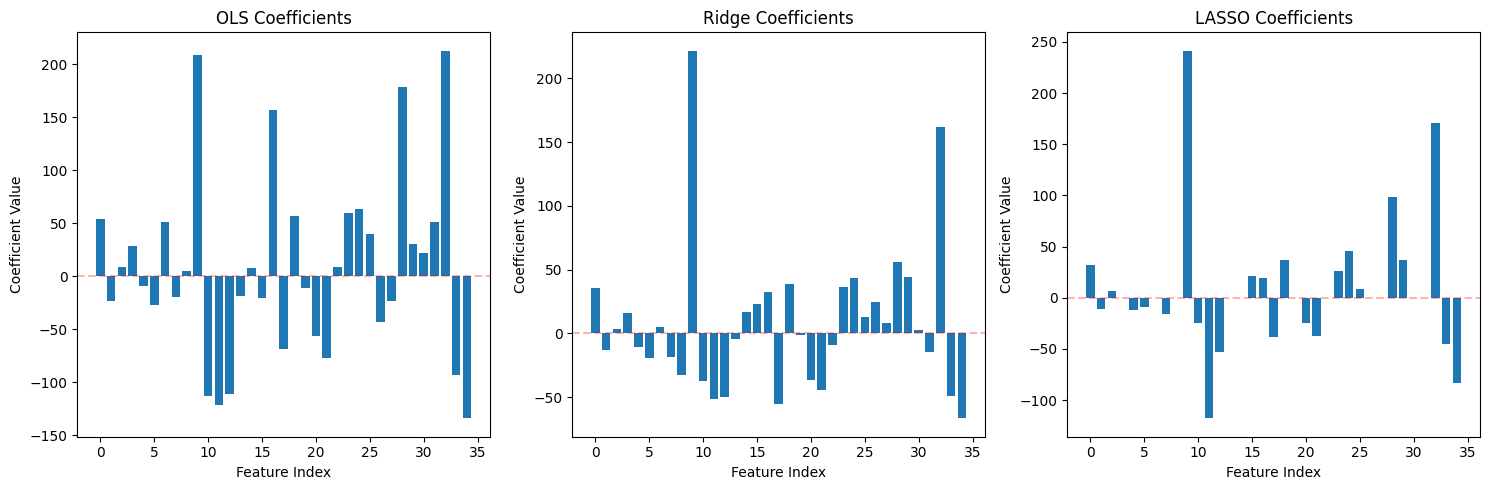

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, coefs) in zip(axes, [("OLS", ols_coefs),
                                    ("Ridge", ridge_coefs),
                                    ("LASSO", lasso_coefs)]):
    ax.bar(range(len(coefs)), coefs)
    ax.set_title(f"{name} Coefficients")
    ax.set_xlabel("Feature Index")
    ax.set_ylabel("Coefficient Value")
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

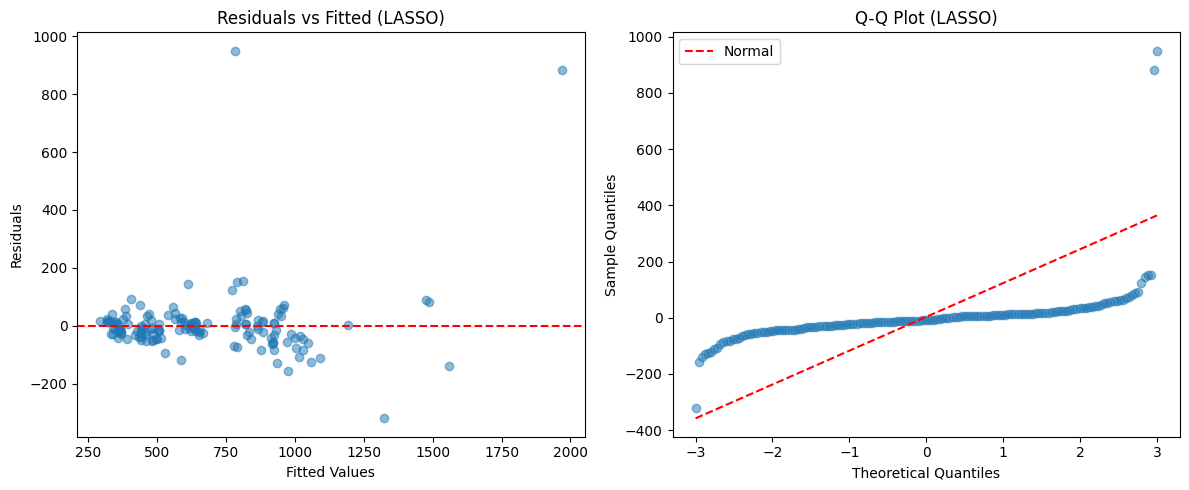

In [43]:
from sklearn.model_selection import cross_val_predict
import numpy as np

y_pred_lasso = cross_val_predict(models["LASSO"], X, y, cv=kf)

# Ensure both are clean 1D numpy arrays
y_array = np.asarray(y).flatten()
y_pred_array = np.asarray(y_pred_lasso).flatten()

residuals = y_array - y_pred_array

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_array, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (LASSO)")

# Manual Q-Q plot
sorted_residuals = np.sort(residuals)
theoretical_quantiles = np.linspace(-3, 3, len(residuals))
axes[1].scatter(theoretical_quantiles, sorted_residuals, alpha=0.5)
axes[1].plot(theoretical_quantiles, theoretical_quantiles * np.std(residuals) + np.mean(residuals),
             'r--', label='Normal')
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title("Q-Q Plot (LASSO)")
axes[1].legend()

plt.tight_layout()
plt.show()

/Users/skylerak/Library/CloudStorage/OneDrive-WashingtonStateUniversity(email.wsu.edu)/EDPSYCH 521/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.537e+05, tolerance: 8.389e+03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/skylerak/Library/CloudStorage/OneDrive-WashingtonStateUniversity(email.wsu.edu)/EDPSYCH 521/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.781e+05, tolerance: 8.389e+03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/skylerak/Library/CloudStorage/OneDrive-WashingtonStateUniversity(email.wsu.edu)/EDPSYCH 521/.venv

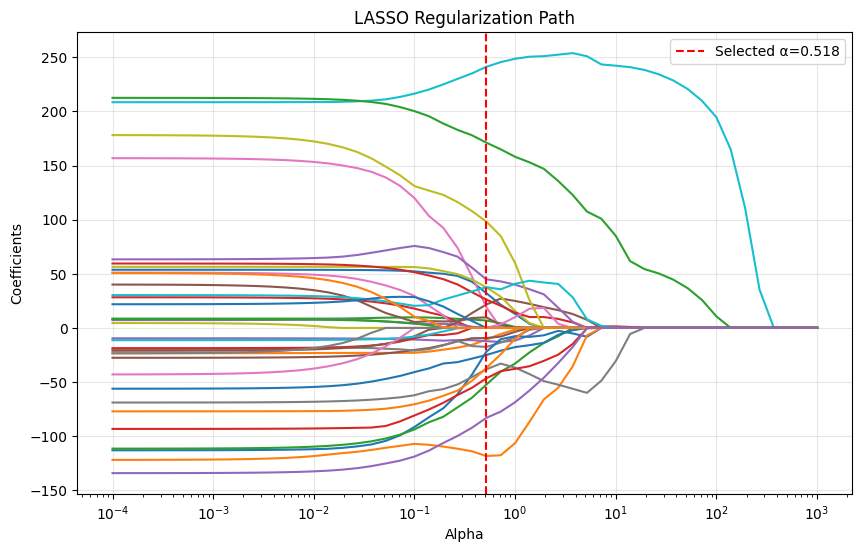

In [44]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(
    models["LASSO"].named_steps["standardscaler"].transform(X),
    y,
    alphas=alpha_grid
)

plt.figure(figsize=(10, 6))
for coef in coefs_path:
    plt.plot(alphas_path, coef)
plt.axvline(lasso_alpha, color='r', linestyle='--',
            label=f'Selected α={lasso_alpha:.3f}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('LASSO Regularization Path')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

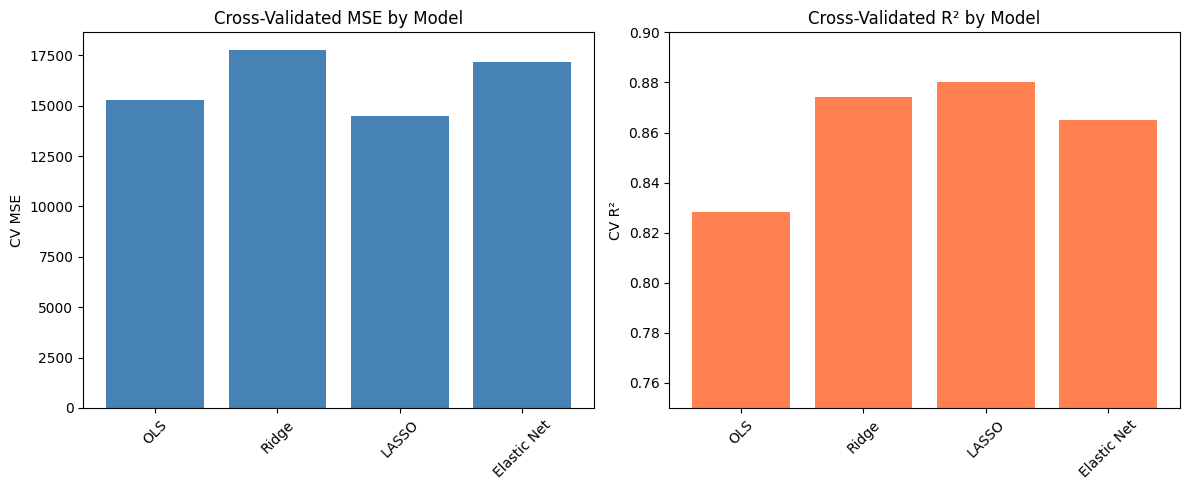

In [45]:
results_df = pd.DataFrame(results, columns=["Model", "CV_MSE", "CV_R2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MSE comparison
axes[0].bar(results_df["Model"], results_df["CV_MSE"], color='steelblue')
axes[0].set_ylabel("CV MSE")
axes[0].set_title("Cross-Validated MSE by Model")
axes[0].tick_params(axis='x', rotation=45)

# R² comparison
axes[1].bar(results_df["Model"], results_df["CV_R2"], color='coral')
axes[1].set_ylabel("CV R²")
axes[1].set_title("Cross-Validated R² by Model")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0.75, 0.90])  # adjust as needed

plt.tight_layout()
plt.show()

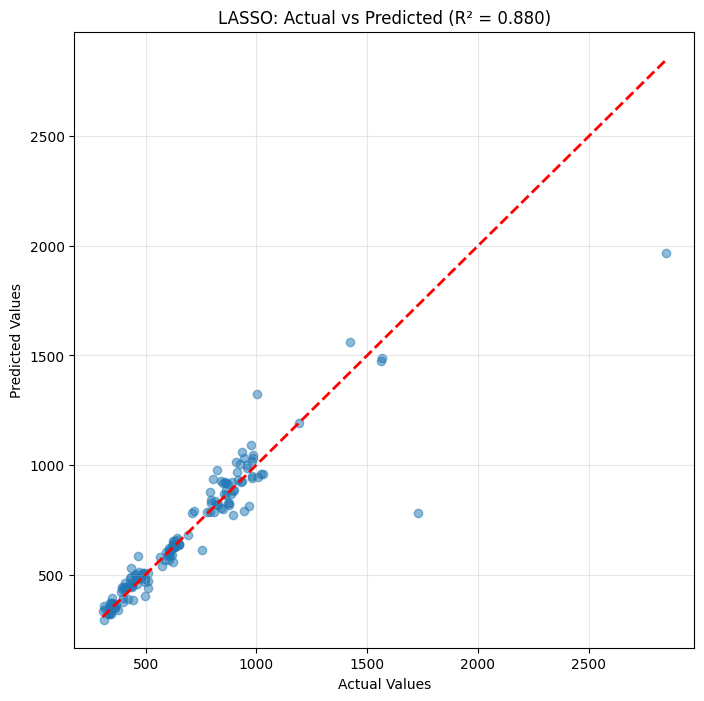

In [46]:
y_pred_lasso = cross_val_predict(models["LASSO"], X, y, cv=kf)

plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred_lasso, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"LASSO: Actual vs Predicted (R² = {results[2][2]:.3f})")
plt.grid(True, alpha=0.3)
plt.show()